In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats


In [26]:
# load the data from the CSV file
df = pd.read_csv("data.csv")
df.head()



,Rk,Squad,MP,W,D,L,GF,GA,GD,Pts,Top Team Scorer,Goalkeeper,Notes
0,1,es Spain,8,7,1,0,14,1,13,22,Mikel Oyarzabal - 5,Unai Simón,NaN
1,2,ar Argentina,8,7,0,1,19,8,11,21,Lionel Messi - 8,Emiliano Martínez,NaN
2,3,eng England,8,6,1,1,20,12,8,19,Jude Bellingham - 7,Jordan Pickford,NaN
3,4,fr France,8,6,0,2,20,10,10,18,Kylian Mbappé - 10,Mike Maignan,NaN
4,QF,no Norway,6,4,0,2,13,11,2,12,Erling Haaland - 7,Ørjan Nyland,NaN


In [27]:
# features in the dataset
df.columns

Index(['Rk', 'Squad', 'MP', 'W', 'D', 'L', 'GF', 'GA', 'GD', 'Pts',
       'Top Team Scorer', 'Goalkeeper', 'Notes'],
      dtype='str')

In [28]:
df["Pts"] = pd.to_numeric(df["Pts"], errors="coerce")
df["Pts"].isnull().sum()

np.int64(0)

In [29]:
df["Rk"].value_counts()

Rk
R32    16
GR     16
R16     8
QF      4
1       1
2       1
3       1
4       1
Name: count, dtype: int64

In [30]:
group_stage = df[df["Rk"] == "GR"].copy()
knockout_stage = df[df["Rk"] != "GR"].copy()
print("Group-stage teams:")
print(group_stage[["Squad", "Pts", "Rk"]])

print("\nKnockout-stage teams:")
print(knockout_stage[["Squad", "Pts", "Rk"]])

Group-stage teams:
                Squad  Pts  Rk
32         ir IR Iran    3  GR
33  kr Korea Republic    3  GR
34         tr Türkiye    3  GR
35       sct Scotland    3  GR
36         uy Uruguay    2  GR
37    sa Saudi Arabia    2  GR
38         cz Czechia    1  GR
39     nz New Zealand    1  GR
40           qa Qatar    1  GR
41         cw Curaçao    1  GR
42          pa Panama    0  GR
43          jo Jordan    0  GR
44           ht Haiti    0  GR
45      uz Uzbekistan    0  GR
46         tn Tunisia    0  GR
47            iq Iraq    0  GR

Knockout-stage teams:
               Squad  Pts   Rk
0           es Spain   22    1
1       ar Argentina   21    2
2        eng England   19    3
3          fr France   18    4
4          no Norway   12   QF
5         be Belgium   11   QF
6         ma Morocco   11   QF
7     ch Switzerland   11   QF
8          mx Mexico   12  R16
9        co Colombia   11  R16
10         br Brazil   10  R16
11            us USA    9  R16
12       pt Portugal    8  R

In [31]:
print("Group-stage teams:", len(group_stage))
print("Knockout-stage teams:", len(knockout_stage))

Group-stage teams: 16
Knockout-stage teams: 32


In [32]:
sample_size = min(8, len(group_stage), len(knockout_stage))

group_sample = group_stage.sample(
    n=sample_size,
    random_state=42
)

knockout_sample = knockout_stage.sample(
    n=sample_size,
    random_state=42
)
sample = pd.concat([group_sample, knockout_sample])
sample[["Squad", "Pts", "Rk"]]

,Squad,Pts,Rk
32,ir IR Iran,3,GR
33,kr Korea Republic,3,GR
37,sa Saudi Arabia,2,GR
46,tn Tunisia,0,GR
45,uz Uzbekistan,0,GR
43,jo Jordan,0,GR
40,qa Qatar,1,GR
41,cw Curaçao,1,GR
29,dz Algeria,4,R32
15,py Paraguay,5,R16


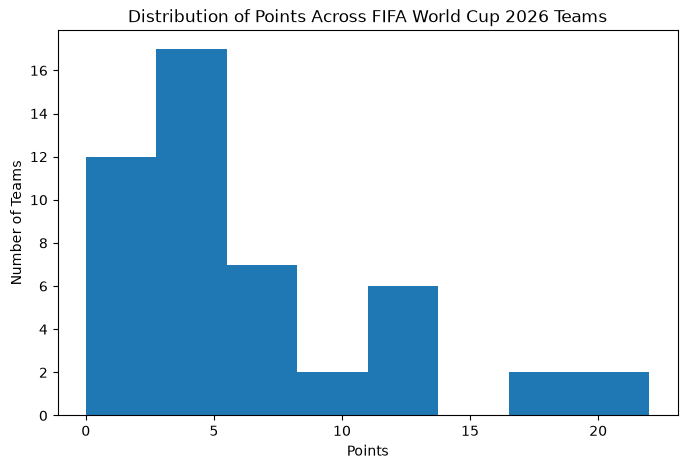

In [33]:
plt.figure(figsize=(8, 5))
plt.hist(df["Pts"], bins=8)
plt.xlabel("Points")
plt.ylabel("Number of Teams")
plt.title("Distribution of Points Across FIFA World Cup 2026 Teams")
plt.show()

In [34]:
group_sample["Pts"].describe()
knockout_sample["Pts"].describe()
print("Group-stage teams")
print("Mean:", group_sample["Pts"].mean())
print("Standard deviation:", group_sample["Pts"].std())
print("Minimum:", group_sample["Pts"].min())
print("Maximum:", group_sample["Pts"].max())

print("\nKnockout-stage teams")
print("Mean:", knockout_sample["Pts"].mean())
print("Standard deviation:", knockout_sample["Pts"].std())
print("Minimum:", knockout_sample["Pts"].min())
print("Maximum:", knockout_sample["Pts"].max())

Group-stage teams
Mean: 1.25
Standard deviation: 1.2817398889233114
Minimum: 0
Maximum: 3

Knockout-stage teams
Mean: 6.25
Standard deviation: 3.453776401067595
Minimum: 3
Maximum: 12


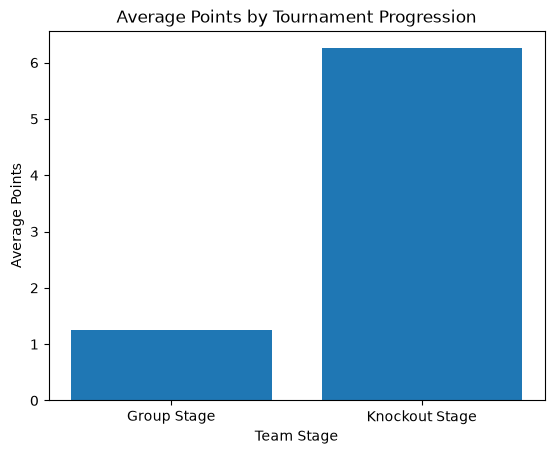

In [35]:
means = [
    group_sample["Pts"].mean(),
    knockout_sample["Pts"].mean()
]

labels = [
    "Group Stage",
    "Knockout Stage"
]

plt.bar(labels, means)
plt.ylabel("Average Points")
plt.xlabel("Team Stage")
plt.title("Average Points by Tournament Progression")
plt.show()

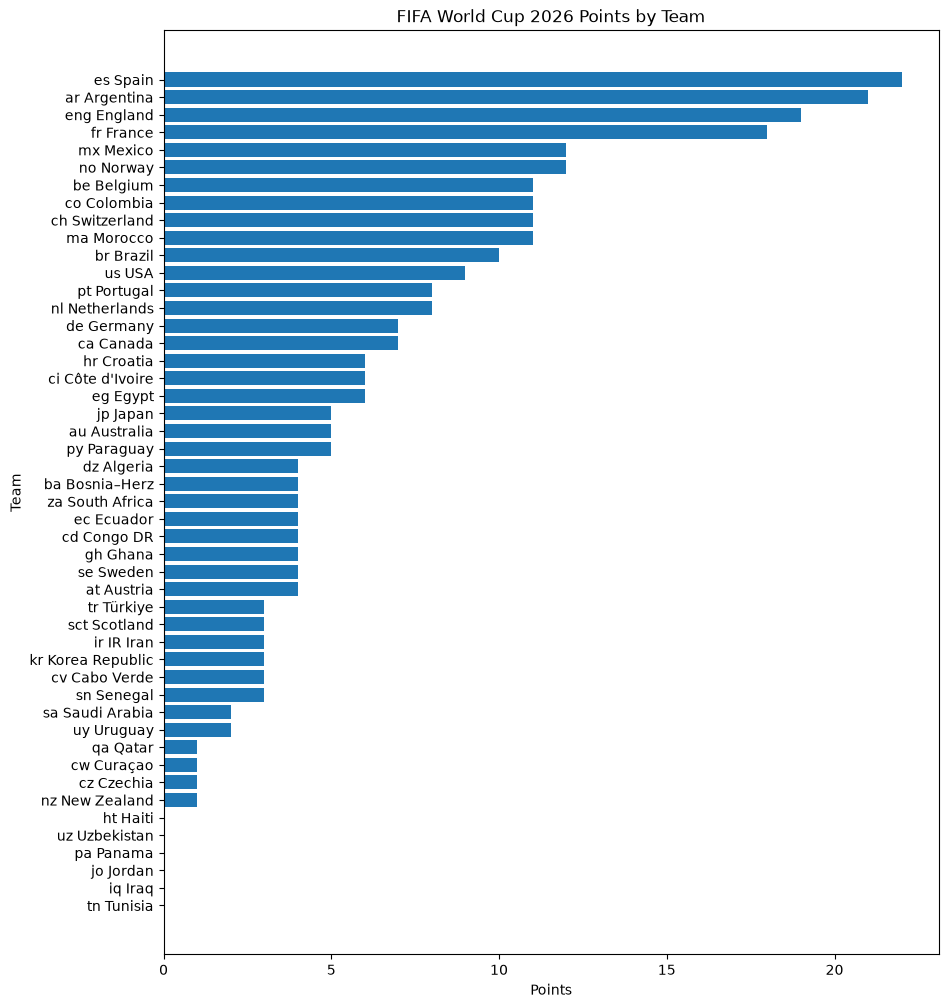

In [36]:
points_sorted = df.sort_values("Pts", ascending=True)

plt.figure(figsize=(10, 12))
plt.barh(points_sorted["Squad"], points_sorted["Pts"])

plt.xlabel("Points")
plt.ylabel("Team")
plt.title("FIFA World Cup 2026 Points by Team")
plt.show()

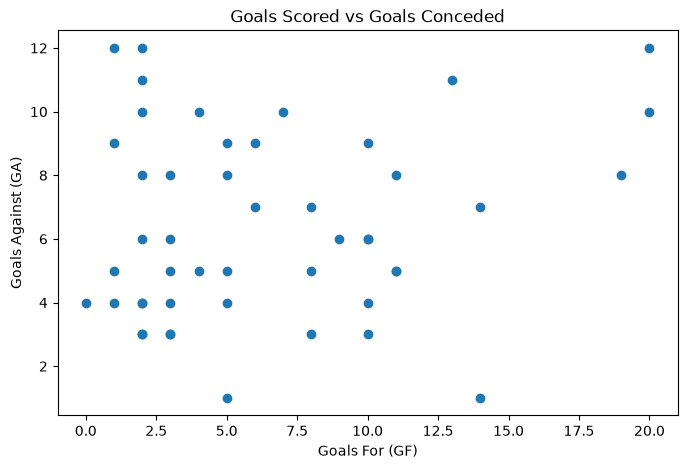

In [37]:
plt.figure(figsize=(8, 5))

plt.scatter(df["GF"], df["GA"])

plt.xlabel("Goals For (GF)")
plt.ylabel("Goals Against (GA)")
plt.title("Goals Scored vs Goals Conceded")
plt.show()

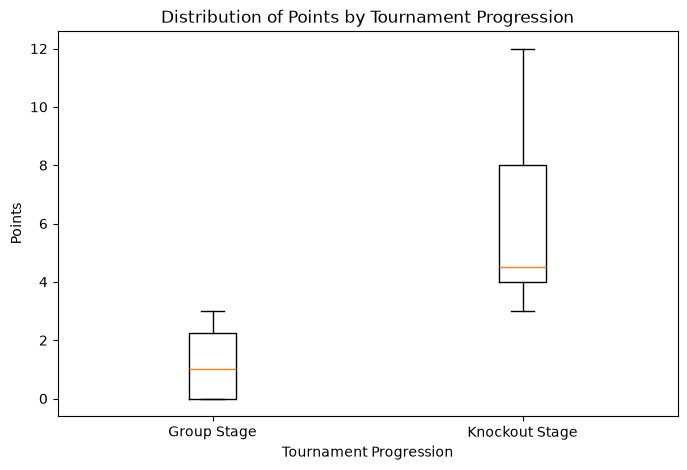

In [38]:
plt.figure(figsize=(8, 5))

plt.boxplot(
    [
        group_sample["Pts"],
        knockout_sample["Pts"]
    ],
    tick_labels=["Group Stage", "Knockout Stage"]
)

plt.xlabel("Tournament Progression")
plt.ylabel("Points")
plt.title("Distribution of Points by Tournament Progression")
plt.show()

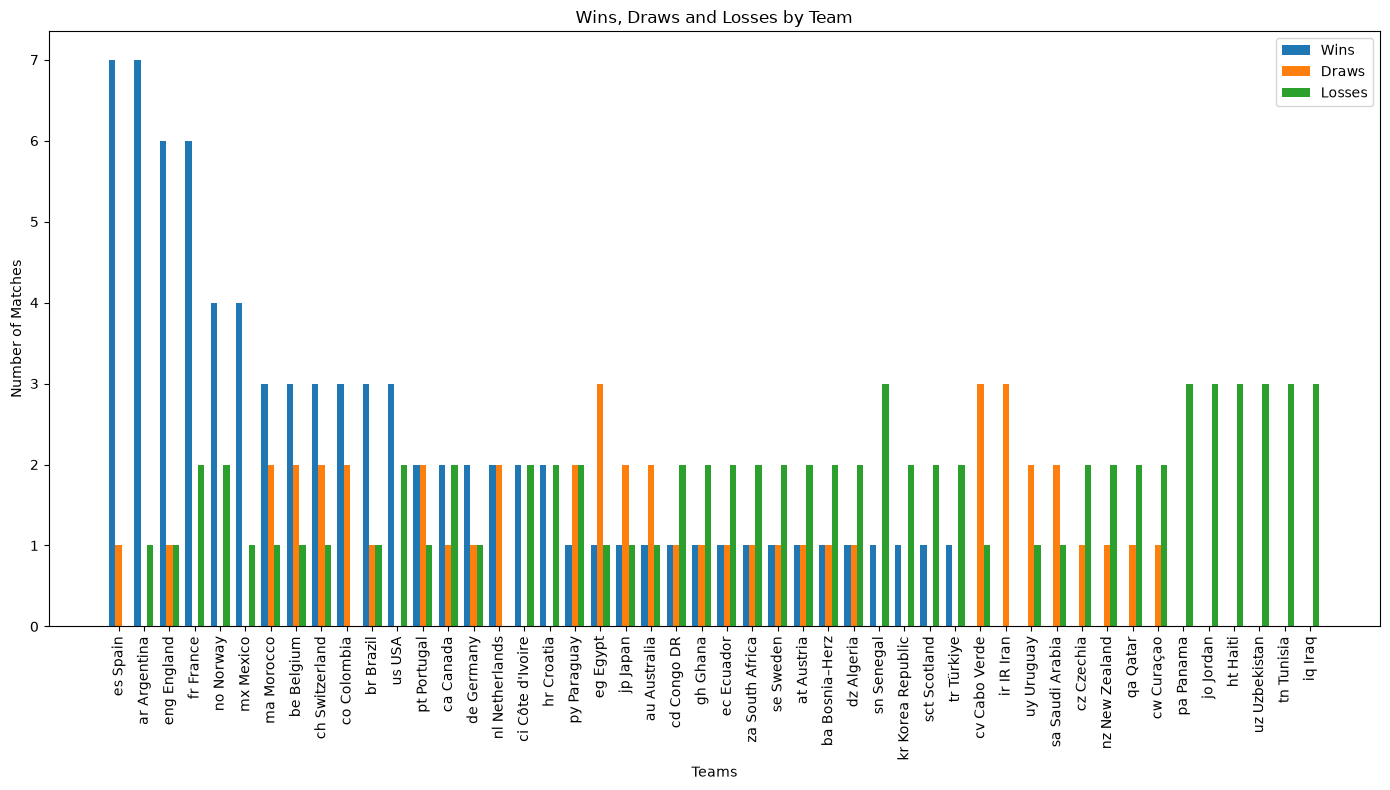

In [39]:
teams = df.sort_values("W", ascending=False)

x = np.arange(len(teams))
width = 0.25

plt.figure(figsize=(14, 8))

plt.bar(x - width, teams["W"], width, label="Wins")
plt.bar(x, teams["D"], width, label="Draws")
plt.bar(x + width, teams["L"], width, label="Losses")

plt.xlabel("Teams")
plt.ylabel("Number of Matches")
plt.title("Wins, Draws and Losses by Team")
plt.xticks(x, teams["Squad"], rotation=90)
plt.legend()

plt.tight_layout()
plt.show()

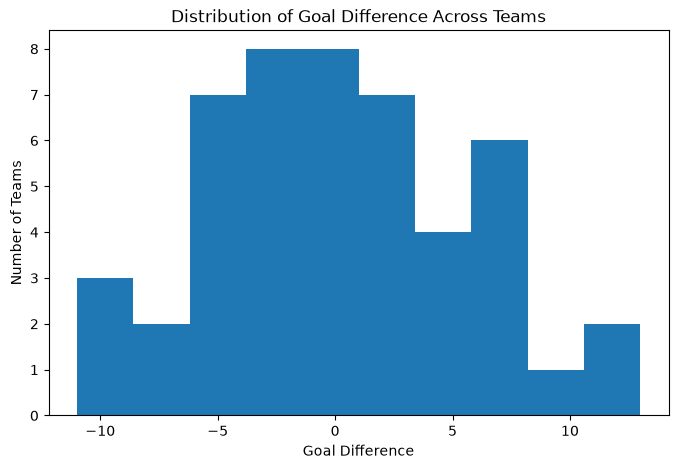

In [40]:
plt.figure(figsize=(8, 5))

plt.hist(df["GD"], bins=10)

plt.xlabel("Goal Difference")
plt.ylabel("Number of Teams")
plt.title("Distribution of Goal Difference Across Teams")
plt.show()

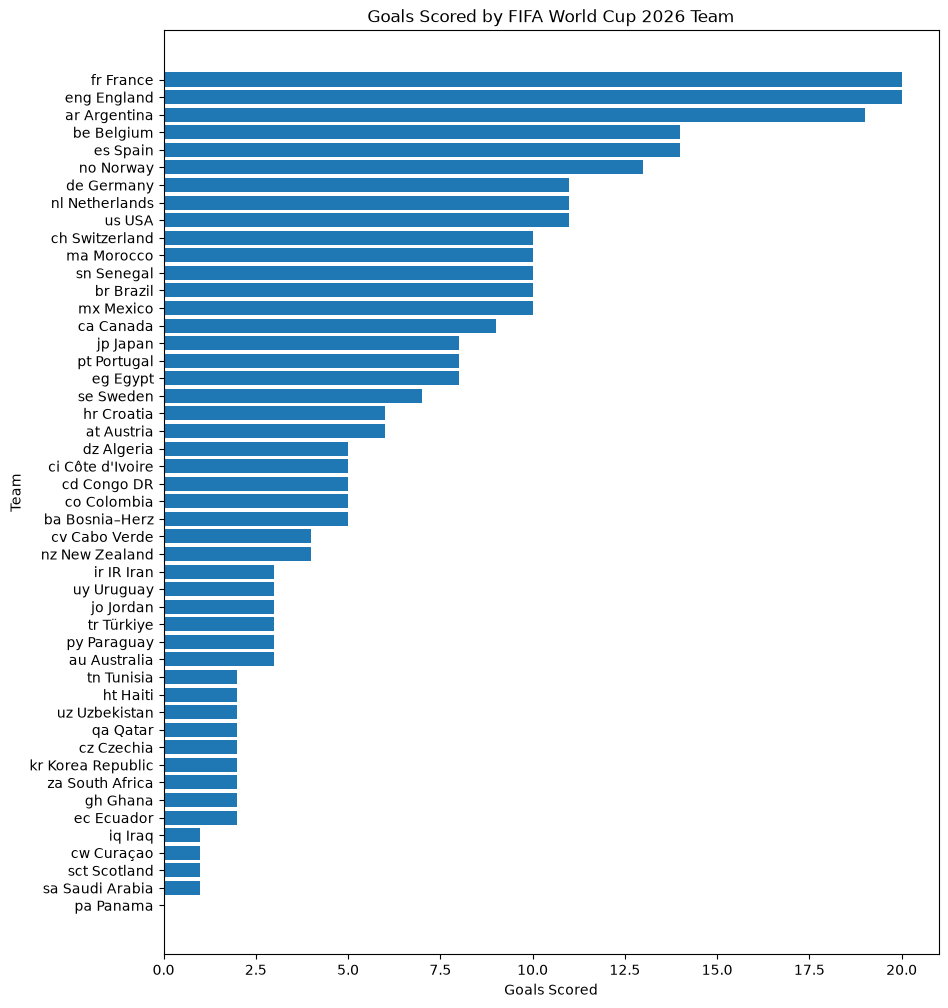

In [41]:
goals_sorted = df.sort_values("GF", ascending=True)

plt.figure(figsize=(10, 12))

plt.barh(goals_sorted["Squad"], goals_sorted["GF"])

plt.xlabel("Goals Scored")
plt.ylabel("Team")
plt.title("Goals Scored by FIFA World Cup 2026 Team")

plt.show()

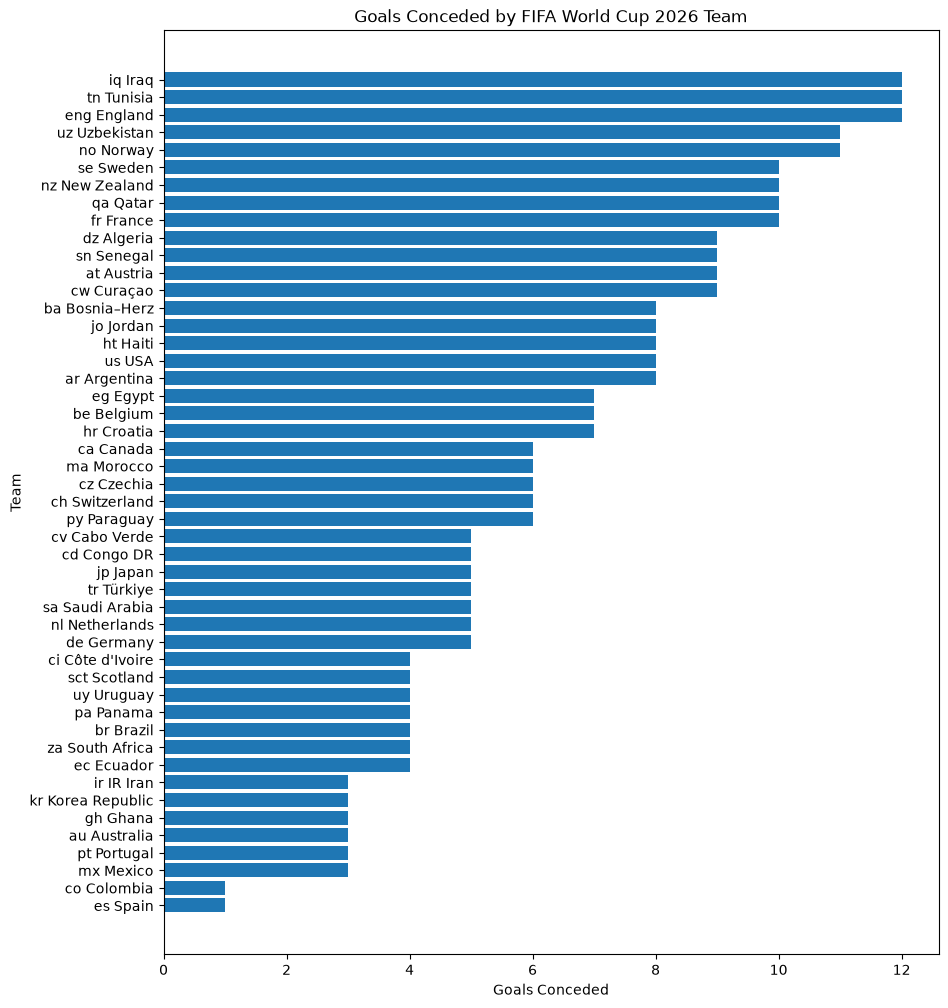

In [42]:
conceded_sorted = df.sort_values("GA", ascending=True)

plt.figure(figsize=(10, 12))

plt.barh(conceded_sorted["Squad"], conceded_sorted["GA"])

plt.xlabel("Goals Conceded")
plt.ylabel("Team")
plt.title("Goals Conceded by FIFA World Cup 2026 Team")

plt.show()

In [43]:
group_mean = group_sample["Pts"].mean()
group_std = group_sample["Pts"].std()
group_n = len(group_sample)

group_se = group_std / np.sqrt(group_n)

group_ci = stats.t.interval(
    confidence=0.95,
    df=group_n - 1,
    loc=group_mean,
    scale=group_se
)

print("Group-stage 95% CI:", group_ci)

Group-stage 95% CI: (np.float64(0.1784386367727695), np.float64(2.3215613632272305))


In [44]:
knockout_mean = knockout_sample["Pts"].mean()
knockout_std = knockout_sample["Pts"].std()
knockout_n = len(knockout_sample)

knockout_se = knockout_std / np.sqrt(knockout_n)

knockout_ci = stats.t.interval(
    confidence=0.95,
    df=knockout_n - 1,
    loc=knockout_mean,
    scale=knockout_se
)

print("Knockout-stage 95% CI:", knockout_ci)

Knockout-stage 95% CI: (np.float64(3.362570670076522), np.float64(9.137429329923478))


In [45]:
t_stat, p_value_two = stats.ttest_ind(
    knockout_sample["Pts"],
    group_sample["Pts"],
    equal_var=False
)

# One-tailed test: knockout stage > group stage
p_value = p_value_two / 2

print("t-statistic:", t_stat)
print("one-tailed p-value:", p_value)

t-statistic: 3.8388594797495728
one-tailed p-value: 0.0020317963123352846


In [46]:
alpha = 0.05

if p_value < alpha:
    print("Reject the null hypothesis (H0).")
else:
    print("Fail to reject the null hypothesis (H0).")

Reject the null hypothesis (H0).


In [47]:
results = pd.DataFrame({
    "Group": ["Group Stage", "Knockout Stage"],
    "Sample Size": [group_n, knockout_n],
    "Mean Points": [
        group_sample["Pts"].mean(),
        knockout_sample["Pts"].mean()
    ],
    "Standard Deviation": [
        group_sample["Pts"].std(),
        knockout_sample["Pts"].std()
    ],
    "95% CI Lower": [
        group_ci[0],
        knockout_ci[0]
    ],
    "95% CI Upper": [
        group_ci[1],
        knockout_ci[1]
    ]
})

results

,Group,Sample Size,Mean Points,Standard Deviation,95% CI Lower,95% CI Upper
0,Group Stage,8,1.25,1.281740,0.178439,2.321561
1,Knockout Stage,8,6.25,3.453776,3.362571,9.137429
